In [107]:
import numpy as np
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Spatial Impulse Response

In [108]:
import numpy as np
from tqdm import tqdm
from time import time as time

pi = np.pi
def compute_rectangle_SIR(wx, wy, xp, yp, l, c0, apod, delay, dt):
    
    xp_abs = abs(xp) * wx / c0  # us
    yp_abs = abs(yp) * wy / c0
    Dt1 = max(min(xp_abs, yp_abs), dt)
    Dt2 = max(max(xp_abs, yp_abs), dt)

    area = wx * wy / (2 * pi * l)
    t1 = l / c0 - 0.5 * (Dt1 + Dt2) + delay
    t2 = t1 + Dt1
    t3 = t1 + Dt2
    t4 = t1 + Dt1 + Dt2

    h_max = area / Dt2 * apod

    return t1, t2, t3, t4, h_max


def compute_all_events(
    P, M, pts, centers, wx, wy, c, apodization, delays, events, dt
):
    for p in range(P):
        for i in range(M):
            dx = pts[p, 0] - centers[i, 0]
            dy = pts[p, 1] - centers[i, 1]
            dz = pts[p, 2] - centers[i, 2]
            dist = np.sqrt(dx * dx + dy * dy + dz * dz)
            xp, yp = dx / (dist), dy / (dist)
            t1, t2, t3, t4, h_max = compute_rectangle_SIR(
                wx,
                wy,
                xp,
                yp,
                dist,
                c,
                apodization[i],
                delays[i],
                dt,
            )
            events[p, i, 0] = t1
            events[p, i, 1] = t2
            events[p, i, 2] = t3
            events[p, i, 3] = t4
            events[p, i, 4] = h_max

## 1.1. Background Theory

## 1.2. Naive method

From the development presented in [] we know that the far-field SIR for a rectangular aperture is expressed as


$
f(x) = \left\{\begin{array}{ll}
      0 & x\leq a \\
      \frac{x-a}{b-a} & a\leq x\leq b \\
      \frac{c-x}{c-b} & b\leq x\leq c \\
      1 & c\leq x \\
\end{array}\right.
$

So let's start with a function that will compute this events

In [109]:
def naive_accumulation_of_events(P, M, T, events, fs, t0, time_grid):

    h_out = np.zeros((P, T), dtype=np.float32)
    range_k = np.zeros(P*M, dtype=np.int32)
    for p in range(P):
        for i in range(M):
            t1, t2, t3, t4, h_max = (
                events[p, i, 0],
                events[p, i, 1],
                events[p, i, 2],
                events[p, i, 3],
                events[p, i, 4],
            )

            # find the first/last sample indices that could possibly overlap
            s1 = h_max / (t2 - t1)  # area under the rising edge    
            k_start = int(np.floor((t1 - t0) * fs))
            k_end = int(np.ceil((t4 - t0) * fs) + 1)

            range_k[p+i] = k_end - k_start

            # clamp to valid range
            if k_end < 0 or k_start >= T-1:
                continue
            if k_start < 0:
                k_start = 0
            if k_end > T-1:
                k_end = T-1

            # loop over every sample that might see part of this trapezoid
            for k in range(k_start, k_end):
                t = time_grid[k]
                # evaluate continuous trapezoid h(t)
                if t < t1 or t >= t4:
                    continue
                elif t < t2:
                    h = s1 * (t - t1) 
                elif t < t3:
                    h = h_max
                else:
                    h = s1 * (t4 - t)

                # accumulate
                h_out[p, k] += h
                
    return h_out, range_k


## 1.3. Sparse Delta Integration (SDI)

In [110]:
def sdi_accumulation_of_events(P, M, T, events, fs, t0):
    """
    Parallel accumulation of trapezoidal SIR contributions for all patches.
    events shape: (P, M, 5) storing t1, t2, t3, t4, h_max.
    h_out: (P, n2) output array, t0: start time, fs: sampling rate.
    """
    dt = 1.0 / fs
    d2h_sir = np.zeros((P, T) , dtype=np.float32)  # extra padding to avoid boundary issues
    for p in range(P):
        for i in range(M):
            t1, t2, t3, t4, h_max = (
                events[p, i, 0],
                events[p, i, 1],
                events[p, i, 2],
                events[p, i, 3],
                events[p, i, 4],
            )
            s1 = h_max / (t2 - t1)
            for ti, sign in zip([t1, t2, t3, t4], [1, -1, -1, 1]):
                k_t = (ti - t0) * fs + 1
                k_floor = int(np.floor(k_t))
                k_ceil = k_floor + 1
                k_floor = max(min(k_floor, T-1), 0)
                k_ceil = max(min(k_ceil, T-1), 0)
                w_ceil = k_t - k_floor
                w_floor = 1 - w_ceil
                d2h_sir[p, k_floor] += sign * s1 * w_floor
                d2h_sir[p, k_ceil] += sign * s1 * w_ceil

    dh_sir = np.cumsum(d2h_sir, axis=1)
    h_out = np.cumsum(dh_sir, axis=1) * dt
    return h_out


We can now create a simplified class that computes the SIR and the pressure field for a given transducer object

# 2. Pressure field

## 2.1. Create PyField Class

In [ ]:
import time

class PyFieldv1:
    def __init__(self, transducer, method='Naive'):

        self.method = method
        self.tx = transducer
        self.c = 1540.0
        self.fs = 200e6  # Hz
        self.fc = transducer.fc  # Hz
        self.lambda_mm = self.c / self.fc
        # compute patch centers/apodization/delays once
        el_h = self.tx.el_h / self.tx.no_sub_y
        el_w = self.tx.el_w / self.tx.no_sub_x
        self.wx = el_w
        self.wy = el_h
        centers, apodization, delays = [], [], []
        for elem in range(self.tx.n_elements):
            for sub_elem in range(self.tx.no_sub_x * self.tx.no_sub_y):
                verts = self.tx.sub_quad_verts[
                    elem * (self.tx.no_sub_x * self.tx.no_sub_y) + sub_elem
                ]
                centers.append(verts.mean(axis=0))
                apodization.append(self.tx.apodization[elem])
                delays.append(self.tx.delays[elem])
        self.centers = np.array(centers, dtype=np.float32)
        self.apodization = np.array(apodization, dtype=np.float32)
        self.delays = np.array(delays, dtype=np.float32)
        self.range_k = None
        self.T_M = None 

    def compute_sir(self, pts, *, method='Naive', return_all=False):
        start = time.time()

        P, M = pts.shape[0], self.centers.shape[0]

        print(f"Computing Pressure field for {P} points and {M} patches...")
        # allocate events
        events = np.zeros((P, M, 5), dtype=np.float32)
        # compute all event times and amplitudes
        compute_all_events(
            P,
            M,
            pts,
            self.centers,
            self.wx,
            self.wy,
            self.c,
            self.apodization,
            self.delays,
            events,
            1/self.fs,
        )
        end_event = time.time()
        print("Events computed in {:.2f} seconds".format(end_event - start))
                # build global time vector from real event times
        t_grid, t0, T = self._compute_time_grid(events)
        if method == 'Naive':
            h_out, range_k = naive_accumulation_of_events(P, M, T, events, self.fs, t0, t_grid)
            self.range_k = range_k
            self.T_M = T/M
        elif method == 'SDI':
            h_out = sdi_accumulation_of_events(P, M, T, events, self.fs, t0)
        else:
            raise ValueError("Method must be either 'Naive' or 'SDI'.")

        print(f"SIR computed in {time.time() - end_event:.2f} seconds...")

        if return_all:
            return t_grid, h_out.T, events
        return t0, h_out.T

    def from_sir_to_pressure(self, h_sir, x, y, z):
        
        start = time.time()
        # Perform FFT along the first axis
        h_sir_FT = np.fft.fft(
            h_sir, axis=0
        )
        # Generate the frequency vector
        freq_vect = np.linspace(0, self.fs, h_sir_FT.shape[0])

        # Find the index of the desired frequency
        idx_freq = np.argmin((freq_vect - self.fc) ** 2)

        # Amplitude for the given frequency
        monochrom_pressure = np.abs(
            h_sir_FT[idx_freq, :]
        ).reshape(z.shape[0], x.shape[0], y.shape[0]
        ).transpose(1, 2, 0)
        print(f"SIR transformed to pressure field in {time.time() - start:.2f} seconds...")

        return monochrom_pressure

    def __call__(self, field_points_mm):
        start = time.time()
        x, y, z, points = self._check_points(field_points_mm)
        t0, h_sir = self.compute_sir(points, method = self.method)
        pressure_field = self.from_sir_to_pressure(h_sir, x, y, z)
        print(f"Field computed in {time.time() - start:.2f} seconds...")
        return x, y, z, pressure_field


    def _check_points(self, field_points_mm):
        if isinstance(field_points_mm, list):
            field_points_mm = np.array(field_points_mm)
        elif isinstance(field_points_mm, np.ndarray):
            pass
        else:
            raise ValueError("field_points_mm must be a list or numpy array")
        
        pts = np.atleast_2d(field_points_mm).astype(np.float32)
        # Check
        x = np.sort(np.unique(pts[:, 0]))
        y = np.sort(np.unique(pts[:, 1]))
        z = np.sort(np.unique(pts[:, 2]))
        spatial_grid = np.array(np.meshgrid(x, y, z)).T.reshape(-1, 3)
        return x, y, z, spatial_grid*1e-3

    def _compute_time_grid(self, events):
        all_times = events[:, :, 0:4]
        t0, tN = all_times.min(), all_times.max()
        # create sampling grid
        dt = 1.0 / self.fs
        num_samples = int(np.ceil((tN - t0) * self.fs))
        # next power of two
        T = 2 ** max(int(np.ceil(np.log2(num_samples))), 5)
        t_grid = t0 + np.arange(T, dtype=np.float32) * dt
        print(f"Time grid from {t0*1e6:.2f} us to {tN*1e6:.2f} us, with {T} samples.")
        return t_grid, t0, T
        

## 2.2. Creation of transducer object

In [112]:
import pysonogen
from pysonogen.transducers import Domino, Zeus_Matrix

focus_mm = np.array([0, 0, 8])
FoverD = 1

x_extent_mm = [-0.2+focus_mm[0], 0.2+focus_mm[0]]
y_extent_mm = [-0.5+focus_mm[1], 0.5+focus_mm[1]]
z_extent_mm = [-0.5 +focus_mm[2], 0.5+focus_mm[2]]
dx_mm = 0.05
dy_mm = 0.05
dz_mm = 0.05

x = np.linspace(x_extent_mm[0], x_extent_mm[1], int((x_extent_mm[1]-x_extent_mm[0])/dx_mm)+1)
y = np.linspace(y_extent_mm[0], y_extent_mm[1], int((y_extent_mm[1]-y_extent_mm[0])/dy_mm)+1)
z = np.linspace(z_extent_mm[0], z_extent_mm[1], int((z_extent_mm[1]-z_extent_mm[0])/dz_mm)+1)
field_point_mm = np.array(np.meshgrid(x, y, z)).T.reshape(-1, 3)
print(f"Number of field points: {field_point_mm.shape[0]}")
print(f"Field points from {field_point_mm.min(axis=0)} mm to {field_point_mm.max(axis=0)} mm")

Number of field points: 3969
Field points from [-0.2 -0.5  7.5] mm to [0.2 0.5 8.5] mm


### 2.2.1. Linear array probe

LinearArrayTransducer initialized in 0.0106 seconds.


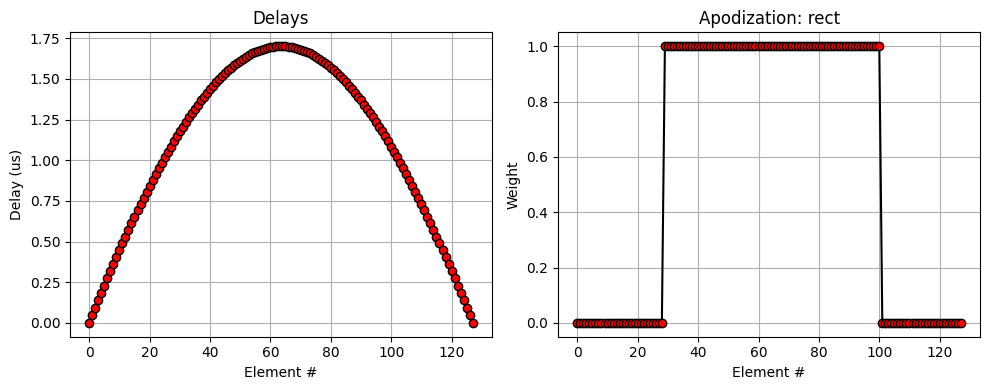

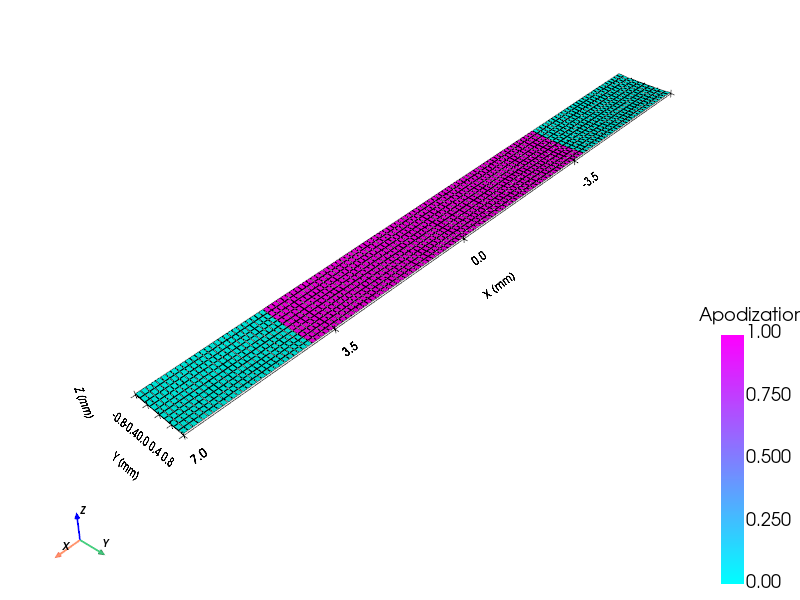

In [113]:
linear_array_probe = Domino()

delays = linear_array_probe.compute_delays(focus_mm=focus_mm)
apodization = linear_array_probe.compute_apodization( 
    focus_mm=focus_mm, FoverD=1)
linear_array_probe.plot_delays_apodization()
linear_array_probe.show(notebook=True, jupyter_backend='static')



### 2.2.1. Matrix array probe

MatrixArrayTransducer initialized with 3025 elements and 12100 patches.
Transducer initialized in 0.0584 seconds.


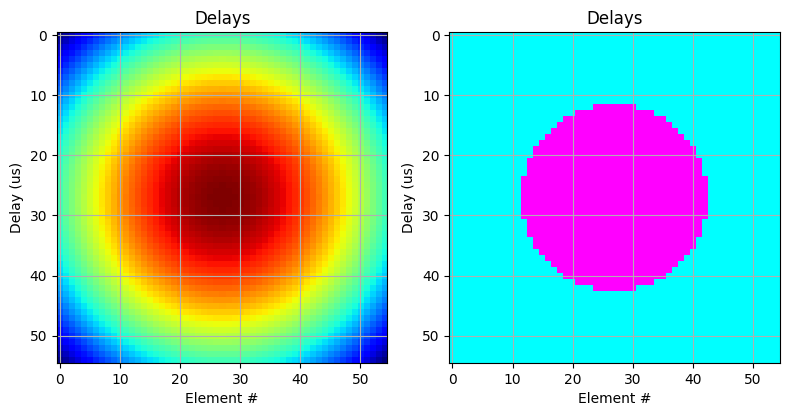

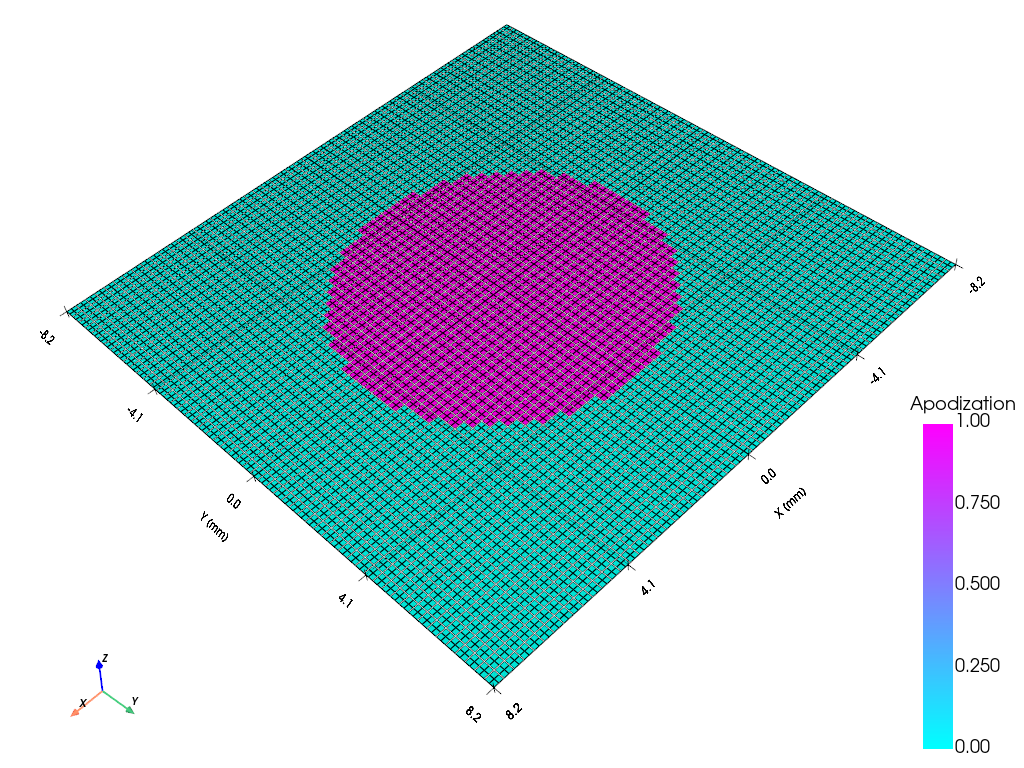

In [114]:
matrix_array_probe = Zeus_Matrix()

delays = matrix_array_probe.compute_delays(focus_mm=focus_mm)
apodization = matrix_array_probe.compute_apodization( 
    focus_mm=focus_mm, FoverD=FoverD)
matrix_array_probe.plot_delays_apodization()
matrix_array_probe.show(notebook=True, jupyter_backend='static')


## 2.3. Test PyField Class

### 2.3.1. Linear array probe

In [115]:
linear_naive_field = PyFieldv1(linear_array_probe, method = 'Naive')

x1, y1, z1, p_field1 = linear_naive_field(field_point_mm)

# When calling the Naive method, the range_k and T_M attributes are computed
# and can be accessed after the first call to the object.
range_k_linear_array = linear_naive_field.range_k
T_M_linear_array = linear_naive_field.T_M

Computing Pressure field for 3969 points and 1280 patches...
Events computed in 15.85 seconds
Time grid from 6.51 us to 7.30 us, with 256 samples.
SIR computed in 21.28 seconds...
SIR transformed to pressure field in 0.01 seconds...


In [116]:
linear_SDI_field = PyFieldv1(linear_array_probe, method = 'SDI')

x2, y2, z2, p_field2 = linear_SDI_field(field_point_mm)

Computing Pressure field for 3969 points and 1280 patches...
Events computed in 16.44 seconds
Time grid from 6.51 us to 7.30 us, with 256 samples.
SIR computed in 41.45 seconds...
SIR transformed to pressure field in 0.01 seconds...


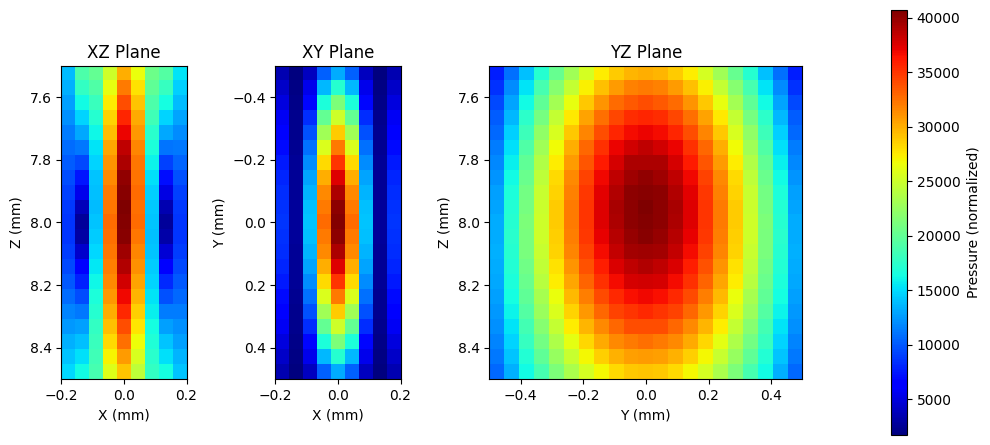

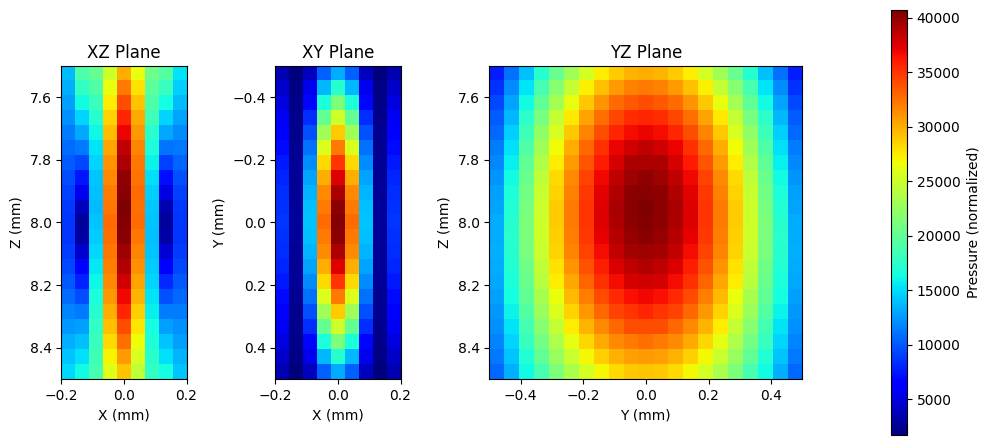

In [117]:
pysonogen.plot_field_planes(p_field1, x1, y1, z1)
pysonogen.plot_field_planes(p_field2, x2, y2, z2)

### 2.3.2. Matrix array probe

In [120]:
matrix_naive_field = PyFieldv1(matrix_array_probe, method = 'Naive')

x1, y1, z1, p_field1 = matrix_naive_field(field_point_mm)

# When calling the Naive method, the range_k and T_M attributes are computed
# and can be accessed after the first call to the object.
range_k_matrix_array = matrix_naive_field.range_k
T_M_matrix_array = matrix_naive_field.T_M

Computing Pressure field for 3969 points and 12100 patches...
Events computed in 148.14 seconds
Time grid from 8.50 us to 9.64 us, with 256 samples.
SIR computed in 308.23 seconds...
SIR transformed to pressure field in 0.01 seconds...


In [ ]:
matrix_SDI_field = PyFieldv1(matrix_array_probe, method = 'SDI')

x2, y2, z2, p_field2 = matrix_SDI_field(field_point_mm)

Computing Pressure field for 3969 points and 12100 patches...


In [ ]:
pysonogen.plot_field_planes(p_field1, x1, y1, z1)
pysonogen.plot_field_planes(p_field2, x2, y2, z2)

In [ ]:
print("Matrix: ")
print(f"kmean: {np.mean(range_k_matrix_array)} and condition number {1+T_M_matrix_array}")
print("Linear: ")
print(f"kmean: {np.mean(range_k_linear_array)} and condition number {1+T_M_linear_array}")

# 3. Visualization

## 3.1. Visualization of spatial impulse response (SIR).

In [ ]:
def plot_apodization_and_delays(tx):
    """
    Plot the apodization and delays of the transducer at specified field points.
    Parameters
    ----------
    tx : LinearArrayTransducer
        The transducer object.
    """

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].plot(tx.apodization)
    ax[0].set_title("Apodization")
    ax[0].set_xlabel("Element index") 
    ax[0].set_ylabel("Apodization")
    ax[0].grid()

    ax[1].plot(tx.delays*1e6)
    ax[1].set_title("Delays (us)")
    ax[1].set_xlabel("Element index")
    ax[1].set_ylabel("Delay (us)")
    ax[1].grid()

    plt.tight_layout()
    plt.show()

    return fig, ax

def plot_sir_subdivision(tx, field, field_point):
    """
    Plot the SIR for each subdivision of the transducer at specified field points.
    Parameters
    ----------
    tx : LinearArrayTransducer
        The transducer object.
    t_tx : ndarray	
        Time vector for the impulse response.
    h_tx : ndarray
        SIR waveform at each of the P points.
    """
    time, h, t_tx, h_tx = field.spatial_impulse_response_subdivision(field_point*1e-3, return_all=True) 
    print(f"SIR shape: {h.shape} ")
    print(f"start_time: {time[0]}")
    # Plot the SIR for each subdivision
    n_elem = tx.n_elements
    n_sub_div = tx.no_sub_x * tx.no_sub_y
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    for p in range(h_tx.shape[0]):
        for elem in range(n_elem):
            for sub_ind in range(n_sub_div):
                # for sub_y in range(tx.no_sub_y):
                    i = elem * n_sub_div + sub_ind
                    ax[0].plot(t_tx[p, i, :]*1e6, h_tx[p, i, :], label=f"Patch {p+1}")
                    if elem < n_elem//2:
                        ax[0].text(t_tx[p, i, 1]*1e6, h_tx[p, i, 1], f"{elem}", fontsize=8)
                    else:
                        ax[0].text(t_tx[p, i, 2]*1e6, h_tx[p, i, 1], f"{elem}", fontsize=8)

    ax[0].set_title("SIR for each subdivision")
    ax[0].set_xlabel("Time (us)")
    ax[0].set_ylabel("SIR")
    ax[0].grid()
    
    ax[1].plot(time*1e6, h)
    ax[1].set_title("SIR for transducer")
    ax[1].set_xlabel("Time (us)")
    ax[1].set_ylabel("SIR")
    ax[1].grid()

    plt.tight_layout()

    return fig, ax
    


### 3.1.1. Creation of Transducer

In [5]:
# Create transducer with elevation focus
n_elements = 128
pitch_mm = 0.11
element_width_mm = 0.108
element_height_mm = 1.5
elevation_focus_mm = 8  # mm
tx_freq = 12.5  # MHz

c = 1540.0  # speed of sound in soft tissue (m/s)

tx = LinearArrayTransducer(
    n_elements         = n_elements,
    element_width_mm   = element_width_mm,
    element_height_mm  = element_height_mm,
    elevation_focus_mm = elevation_focus_mm,
    kerf_mm            = pitch_mm - element_width_mm,
    no_sub_x           = 1,
    no_sub_y           = 2,
    frequency_Hz       = tx_freq*1e6,  # MHz
)


Transducer initialized in 0.0030 seconds.


### 3.1.2. No apodization, No delay-law

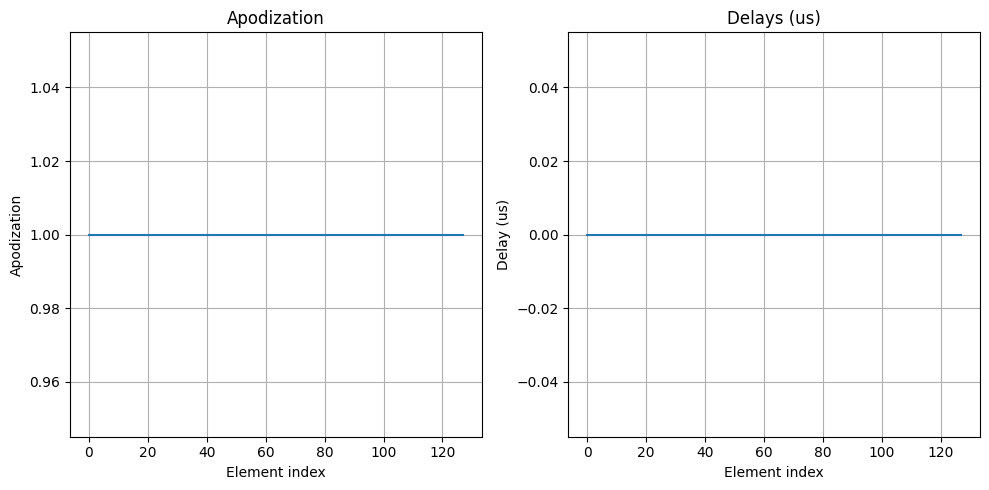

In [6]:
fig, ax = plot_apodization_and_delays(tx)


In [7]:
# Wrap into PyField
field = PyField_v1(tx)

# Select the field point for the SIR computation
field_point = np.array([0, 0, 8])  # mm

In [ ]:
field.show_transducer(notebook=True)

Interpolating: 100%|██████████| 1/1 [00:00<?, ?pt/s]


Total computation time: 0.3565 seconds.
SIR shape: (512, 1) 
start_time: 5.177537148677943e-06


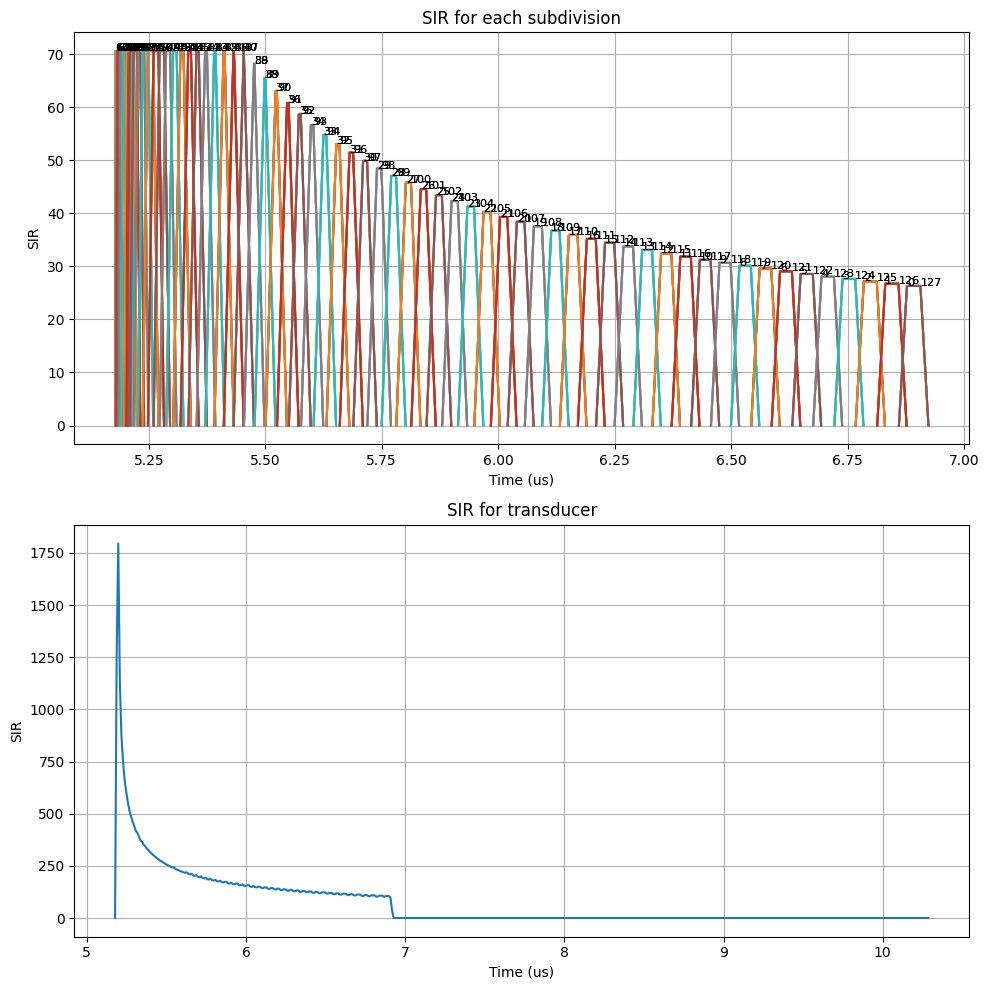

In [9]:
fig = plot_sir_subdivision(tx, field, field_point)

### 3.1.3. Apodzation and delay-law

In [10]:
field_point = np.array([0, 0, 8])  # mm
focus_mm =  np.array([0, 0, 8])  # mm
delays = np.linalg.norm(tx.element_centers - focus_mm*1e-3, axis=1) / c 
delays = delays.min()- delays  # time delays for focusing
tx.set_delays(delays)
tx.set_apodization(np.hanning(n_elements))

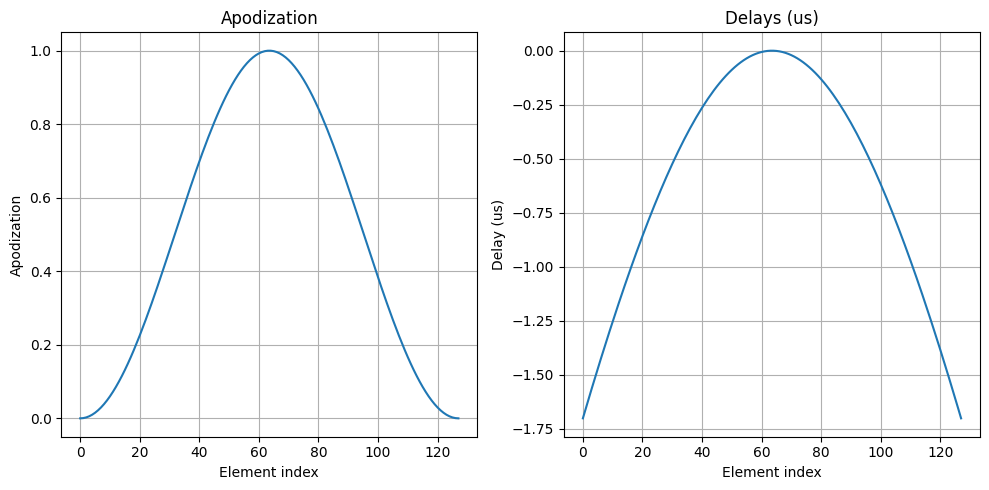

In [11]:
fig, ax = plot_apodization_and_delays(tx)

In [12]:
# Wrap into PyField
field = PyField_v1(tx)

Interpolating: 100%|██████████| 1/1 [00:00<?, ?pt/s]


Total computation time: 0.0067 seconds.
SIR shape: (32, 1) 
start_time: 5.158937712339242e-06


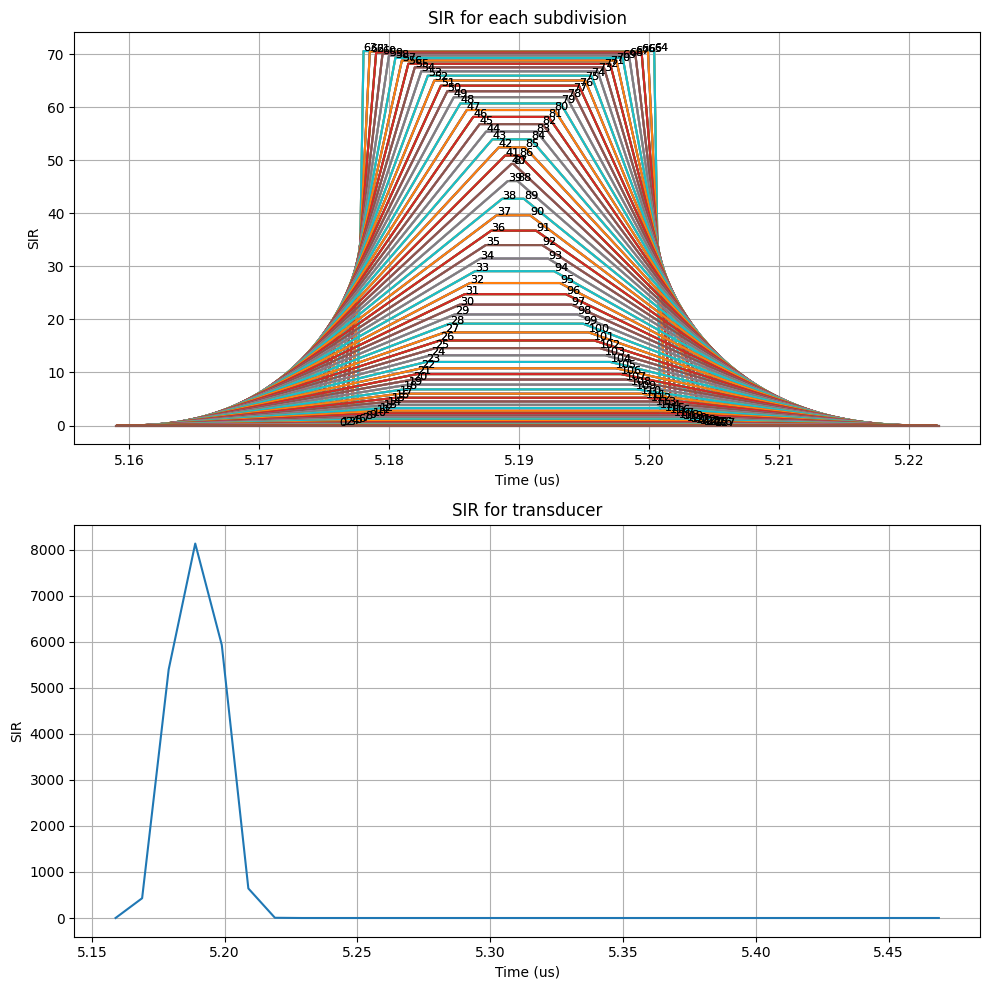

In [13]:
fig = plot_sir_subdivision(tx, field, field_point)

# 4. Real implementation and calculation of field pressure map

## 4.1. Creation of Transducer

In [14]:
# Create transducer with elevation focus
n_elements = 128
pitch_mm = 0.11
element_width_mm = 0.108
element_height_mm = 1.5
elevation_focus_mm = 8  # mm
tx_freq = 12.5  # MHz

c = 1540.0  # speed of sound in soft tissue (m/s)

tx = LinearArrayTransducer(
    n_elements         = n_elements,
    element_width_mm   = element_width_mm,
    element_height_mm  = element_height_mm,
    elevation_focus_mm = elevation_focus_mm,
    kerf_mm            = pitch_mm - element_width_mm,
    no_sub_x           = 1,
    no_sub_y           = 10,
    frequency_Hz       = tx_freq*1e6,  # MHz
)


Transducer initialized in 0.0116 seconds.


In [15]:
focus_mm = np.array([0,0,8])  # mm
delays = np.linalg.norm(tx.element_centers - focus_mm*1e-3, axis=1) / c
delays = delays.min() - delays  # time delays for focusing
tx.set_delays(delays)

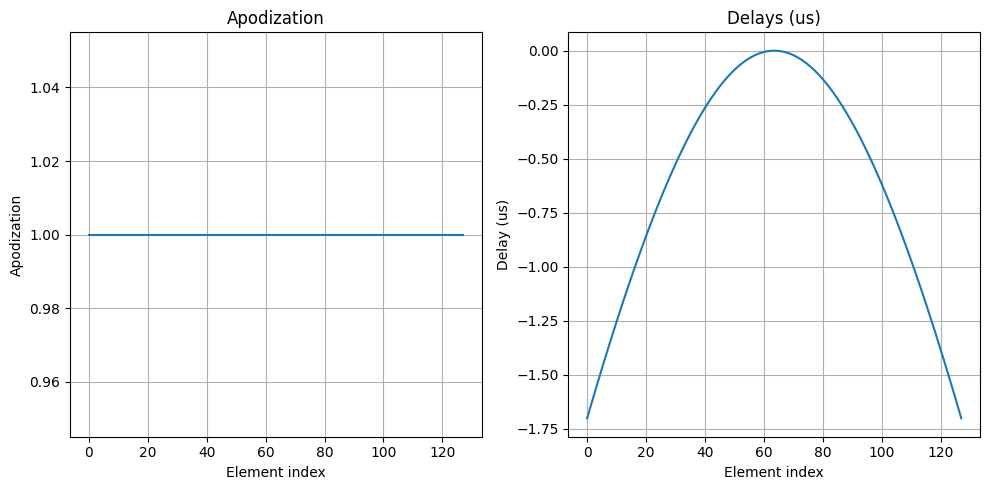

In [16]:
fig = plot_apodization_and_delays(tx)

## 4.2. Creation of grid

In [17]:
def create_simulation_grid(simulation_struct):
    """
    Create a simulation mesh for the ultrasound field.
    
    Parameters
    ----------
    simulation_struct : dict
        Dictionary containing the simulation parameters.
    
    Returns
    -------
    grid_points : ndarray
        Array of points in the simulation space.
    """
    # Create a grid of points in the simulation space
    [x0, xf], [y0, yf], [z0, zf] = simulation_struct["x_extent"], simulation_struct["y_extent"], simulation_struct["z_extent"]
    Nx = int((xf-x0) / simulation_struct["dx"])
    Ny = int((yf-y0) / simulation_struct["dy"])
    Nz = int((zf-z0) / simulation_struct["dz"])
    if Nx % 2 == 0 :
        Nx += 1 
    if Ny % 2 == 0 :
        Ny += 1
    if Nz % 2 == 0 :
        Nz += 1

    x = np.linspace(x0,xf, Nx)
    y = np.linspace(y0,yf, Ny)
    z = np.linspace(z0,zf, Nz)
    # Create a meshgrid of points
    grid_points = np.array(np.meshgrid(x, y, z)).T.reshape(-1, 3)

    return x*1e3, y*1e3, z*1e3, grid_points

In [18]:
simulation_struct = {
    "x_extent" : [-0.5e-3, 0.5e-3],
    "y_extent" : [-0.7e-3, 0.7e-3],
    "z_extent" : [7.2e-3, 8.8e-3],
    "dx" : 0.1e-3,
    "dy" : 0.1e-3,
    "dz" : 0.1e-3,
}

x, y, z, grid_points = create_simulation_grid(simulation_struct)

In [19]:
print(grid_points.shape, x.shape, y.shape, z.shape)

(2805, 3) (11,) (15,) (17,)


## 4.3. Compute SIR and Pressure field

In [20]:
def compute_pressure_from_SIR(h, x, y, z, Frequencies):
    """
    Compute the pressure field from the SIR.
    
    Parameters
    ----------
    h : ndarray
        The SIR data.
    x, y, z : ndarray
        The grid points in the simulation space.
    Frequencies : list
        List of frequencies for the simulation.
        Frequencies[0] is the central frequency of the transducer.
        Frequencies[1] is the sampling frequency.
    Returns
    -------
    pressure : ndarray
        The computed pressure field.
    """

    freq_searched = Frequencies[0]  #  Hz
    sampling_frequency = Frequencies[1]  # Hz

    print(f"Original h shape: {h.shape}")
    spatial_impulse_response_field = h.reshape( -1, z.shape[0], x.shape[0], y.shape[0]).transpose(0, 2, 3, 1)
    print(f"Reshaped h shape: {spatial_impulse_response_field.shape}")

    # Perform FFT along the first axis
    spatial_impulse_response_field_FT = np.fft.fft(spatial_impulse_response_field, axis=0)
    # Generate the frequency vector
    freq_vect = np.linspace(0, sampling_frequency, spatial_impulse_response_field_FT.shape[0])

    # Find the index of the desired frequency
    idx_freq = np.argmin(np.abs(freq_vect - freq_searched))
    print(f"Frequency searched: {freq_searched} Hz, Closest found: {freq_vect[idx_freq]} Hz")

    # Amplitude for the given frequency
    amp_response_tx_freq = np.abs(spatial_impulse_response_field_FT[idx_freq, :, :, :])
    
    pressure_field = amp_response_tx_freq/np.max(amp_response_tx_freq)

    return pressure_field


In [21]:
start_time, h = field.spatial_impulse_response(grid_points) 

Accumulate SIR: 100%|██████████| 2805/2805 [00:05<00:00, 548.63pt/s]

Total computation time: 6.5831 seconds.


In [22]:
pressure_field = compute_pressure_from_SIR(h, x, y, z, [field.fc, field.fs])

Original h shape: (512, 2805)
Reshaped h shape: (512, 11, 15, 17)
Frequency searched: 12500000.0 Hz, Closest found: 12524461.839530332 Hz


## 4.4. Visualize results

In [ ]:
def plot_pressure_field(pressure_field, x, y, z):
    """
    Plot the pressure field in 3D.
    
    Parameters
    ----------
    pressure_field : ndarray
        Pressure field data.
    x, y, z : ndarray
        Coordinate arrays.
    """
    # If x, y, z are 1D (common case)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    dz = z[1] - z[0]

    nx, ny, nz = pressure_field.shape

    # Create the 3D UniformGrid
    pressure_vol = pv.ImageData(dimensions=(nx, ny, nz),
                        spacing=(dx, dy, dz),
                        origin=(x.min(), y.min(), z.min()))

    # Attach pressure data to the grid
    pressure_vol.point_data["Pressure"] = pressure_field.ravel(order="F")  # VERY important: Fortran order
    plotter = pv.Plotter(notebook=True)# ,off_screen=True) # Need to add this parameter to save the screenshot

    n_contours = 10
    min_val = 0
    max_val = pressure_field.max()
    levels = np.linspace(min_val, max_val, n_contours)
    iso_mesh = pressure_vol.contour(isosurfaces=levels, scalars="Pressure")  # Create isosurface at threshold
    plotter.add_mesh(
        iso_mesh,
        scalars="Pressure",  # use the scalar to color surfaces
        cmap="jet",                   # color map
        opacity='linear',                  # solid surfaces
        show_scalar_bar=True,
        scalar_bar_args={"title": "Pressure",
            "vertical": True,
            "title_font_size": 16,
            "label_font_size": 12,
            "position_x": 0.9,
            "position_y": 0.2,
            "height": 0.3,
        },
        label="Pressure PII",
        color = "r", # color of the mesh
    )

    plotter.add_axes()              # show XYZ axes
    plotter.show_grid()             # show grid
    plotter.show()

In [24]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def plot_field_planes(pressure_field, x, y, z, *
                      , interpolation=None):
    """
    Plot the pressure field in 2D slices with a properly placed colorbar.
    
    Parameters
    ----------
    pressure_field : ndarray
        Pressure field data.
    x, y, z : ndarray
        Coordinate arrays.
    """ 
    y0 = int(np.floor(y.shape[0] / 2))
    x0 = int(np.floor(x.shape[0] / 2))
    z0 = int(np.floor(z.shape[0] / 2))
    print(f"Taking slice x_ind, y_ind, z_ind = {x0+1}/{x.shape[0]}, {y0+1}/{y.shape[0]}, {z0+1}/{z.shape[0]}")

    vmin = pressure_field.min()
    vmax = pressure_field.max()

    XZ_plane = pressure_field[:, y0, :].squeeze()
    XY_plane = pressure_field[:, :, z0].squeeze()
    YZ_plane = pressure_field[x0, :, :].squeeze()

    Dx, Dy, Dz = x.max()-x.min(), y.max()-y.min(), z.max()-z.min()
    ratios = [Dx/Dz, Dx/Dy, Dy/Dz]
    ratios = ratios / np.sum(ratios)

    # Create a GridSpec layout
    fig = plt.figure(figsize=(10, 5))
    gs = GridSpec(1, 4, width_ratios=[ratios[0], ratios[1], ratios[2], 0.05*ratios.max()])  # Last column for the colorbar

    ax0 = fig.add_subplot(gs[0, 0])
    im0 = ax0.imshow(XZ_plane.T, cmap='jet', extent=[x.min(), x.max(), z.min(), z.max()], vmin=vmin, vmax=vmax, interpolation=interpolation)
    ax0.set_xlabel("X (mm)")
    ax0.set_ylabel("Z (mm)")
    ax0.set_title("XZ Plane")

    ax1 = fig.add_subplot(gs[0, 1])
    im1 = ax1.imshow(XY_plane.T, cmap='jet', extent=[x.min(), x.max(), y.min(), y.max()], vmin=vmin, vmax=vmax, interpolation=interpolation)
    ax1.set_xlabel("X (mm)")
    ax1.set_ylabel("Y (mm)")
    ax1.set_title("XY Plane")

    ax2 = fig.add_subplot(gs[0, 2])
    im2 = ax2.imshow(YZ_plane.T, cmap='jet', extent=[y.min(), y.max(), z.min(), z.max()], vmin=vmin, vmax=vmax, interpolation=interpolation)
    ax2.set_xlabel("Y (mm)")
    ax2.set_ylabel("Z (mm)")
    ax2.set_title("YZ Plane")

    # Add a colorbar to the last column
    cbar_ax = fig.add_subplot(gs[0, 3])
    cbar = fig.colorbar(im2, cax=cbar_ax)
    cbar.set_label("Pressure (normalized)")

    plt.tight_layout()
    plt.show()


Taking slice x_ind, y_ind, z_ind = 6/11, 8/15, 9/17


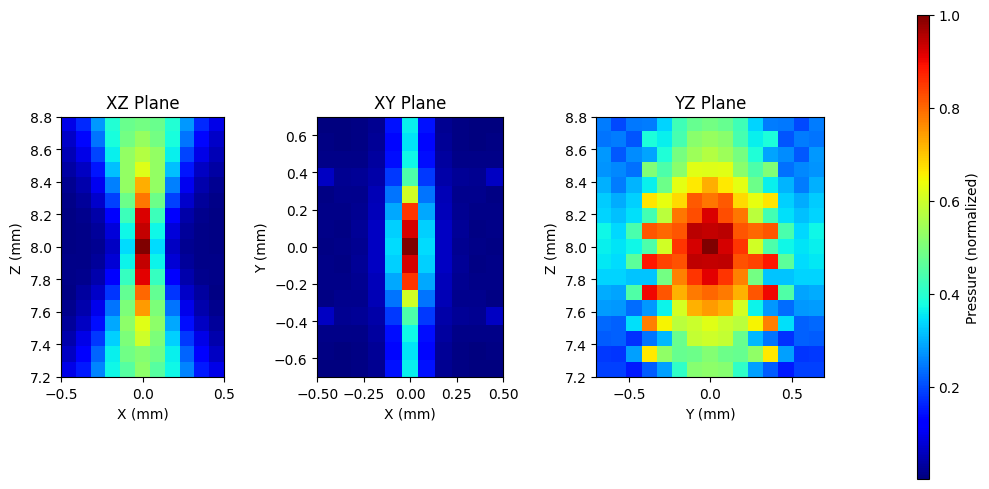

In [25]:
plot_field_planes(pressure_field, x, y, z)

In [26]:
plot_pressure_field(pressure_field, x, y, z)

# 5. Optimized PyField class

In [ ]:
import numpy as np
from tqdm import tqdm
from numba import njit, range

@njit
def compute_patch_sir(wx, wy, xp, yp, l, c0, apod, delay, sampling_rate_Hz, lambda_mm):
    # Common sampling rate is 100 MHz
    # Then minimum time step is 0.01 us, 
    epsilon = 1/(sampling_rate_Hz) # 1 ns
    Dt1 = min(abs(wx * xp / c0), abs(wy * yp / c0))
    Dt2 = max(abs(wx * xp / c0), abs(wy * yp / c0))
    area = wx * wy / (2 * np.pi * l)

    t1 = l / c0 - 0.5 * (Dt1 + Dt2)
    t2 = t1 + Dt1
    t3 = t1 + Dt2
    t4 = t1 + Dt1 + Dt2

    # peak amplitude
    if not (t1 <= t2 <= t3 <= t4):
        raise ValueError("Invalid time sequence in patch SIR")
    
    # avoid division by zero
    width_trapezoid = ((t2 - t1) + (t4 - t3)) * 0.5 + (t3 - t2) if (t4-t1) > epsilon else epsilon

    # trapezoid area
    h_max = area * apod / (width_trapezoid)
    return t1 + delay, t2 + delay, t3 + delay, t4 + delay, h_max

@njit(parallel=True)
def compute_all_events(P, M, pts, centers, wx, wy, c, apods, delays, events, sampling_rate_Hz, lambda_mm):
    for p in range(P):
        for i in range(M):
            dx = pts[p,0] - centers[i,0]
            dy = pts[p,1] - centers[i,1]
            dz = pts[p,2] - centers[i,2]
            dist = (dx*dx + dy*dy + dz*dz)**0.5
                
            xp, yp = dx/(dist), dy/(dist)
            t1, t2, t3, t4, h_max = compute_patch_sir(wx, wy, xp, yp, dist, c,
                                                      apods[i], delays[i], sampling_rate_Hz, lambda_mm)
            events[p,i,0] = t1
            events[p,i,1] = t2
            events[p,i,2] = t3
            events[p,i,3] = t4
            events[p,i,4] = h_max

@njit(parallel=True)
def accumulate_from_events(P, M, events, fs, t0, h_out):
    """
    Parallel accumulation of trapezoidal SIR contributions for all patches.
    events shape: (P, M, 5) storing t1, t2, t3, t4, h_max.
    h_out: (P, n2) output array, t0: start time, fs: sampling rate.
    """
    dt = 1.0 / fs
    n2 = h_out.shape[1]
    for p in range(P):
        for i in range(M):
            t1, t2, t3, t4, h_max = (
                events[p,i,0], events[p,i,1],
                events[p,i,2], events[p,i,3],
                events[p,i,4]
            )            
            k1 = max(0, int((t1 - t0) * fs)+1)
            k2 = min(n2, int((t2 - t0) * fs)+1)
            k3 = min(n2, int((t3 - t0) * fs)+1)
            k4 = min(n2, int((t4 - t0) * fs)+1)
            
            # rising
            for k in range(k1, k2):
                t = t0 + k * dt
                h_out[p,k] += h_max * ((t - t1) / (t2 - t1))
            # plateau
            for k in range(k2, k3):
                h_out[p,k] += h_max
            # falling
            for k in range(k3, k4):
                t = t0 + k * dt
                h_out[p,k] += h_max * (1 - (t - t3) / (t4 - t3))

class PyField:
    def __init__(self, transducer):
        self.tx = transducer
        self.c = 1540.0 
        self.fs = 100e6 # m/s
        self.fc = transducer.fc # Hz
        self.lambda_mm = self.c / self.fc
        # compute patch centers/apods/delays once
        el_h = self.tx.el_h / self.tx.no_sub_y
        el_w = self.tx.el_w / self.tx.no_sub_x
        centers, apods, delays = [], [], []
        for elem in range(self.tx.n_elements):
            for sub_elem in range(self.tx.no_sub_x * self.tx.no_sub_y):
                verts = self.tx.sub_quad_verts[elem*(self.tx.no_sub_x*self.tx.no_sub_y)+sub_elem]
                centers.append(verts.mean(axis=0))
                apods.append(self.tx.apodization[elem])
                delays.append(self.tx.delays[elem])
        self.centers = np.array(centers, dtype=np.float32)
        self.apods = np.array(apods, dtype=np.float32)
        self.delays = np.array(delays, dtype=np.float32)
        self.wx = el_w
        self.wy = el_h
        
    def show_transducer(self, notebook = True, show_edges=True):
        """
        Visualize the transducer surface mesh and apodization with PyVista.
        """
        mesh = self.tx.get_mesh()
        plotter = pv.Plotter(notebook=notebook)
        plotter.add_mesh(
            mesh,  # Convert to mm for visualization
            scalars='Apodization',
            cmap='cool',
            clim=[0, 1],
            show_scalar_bar=True,
            scalar_bar_args={'title':'Apodization', 'vertical': True},
            opacity=1.0,
            show_edges=show_edges,
        )
        plotter.add_axes()
        plotter.show_grid(font_size = 10, xtitle = "X (mm)", ytitle = "Y (mm)", ztitle = "Z (mm)", show_zlabels=False)
        plotter.show()

    def spatial_impulse_response(self, field_points, return_all=False):

        start_comput_time = TIME()
        pts = np.atleast_2d(field_points).astype(np.float32)
        P, M = pts.shape[0], self.centers.shape[0]
        
        # allocate events
        events = np.zeros((P, M, 5), dtype=np.float32)
        tqdm.write("Computing all patch events...")
        compute_all_events(P, M, pts, self.centers, self.wx, self.wy,
                           self.c, self.apods, self.delays, events, self.fs, self.lambda_mm)
        # build global time vector from real event times
        all_times = np.unique(events[:,:,0:4].ravel())
        all_times.sort()
        t0, tN = all_times[0], all_times[-1]
        # create sampling grid
        dt = 1.0/self.fs
        num_samples = int(np.ceil((tN - t0)*self.fs))
        # next power of two
        n2 = 2**max(int(np.ceil(np.log2(num_samples)))+1, 5)
        t_global = t0 + np.arange(n2, dtype=np.float32)*dt
        h_out = np.zeros((P, n2), dtype=np.float32)
        tqdm.write("Accumulating SIR from events...")
        accumulate_from_events(P, M, events, self.fs, t0, h_out)

        print(f"Total computation time: {TIME() - start_comput_time:.4f} seconds.")
        if return_all:
            return t_global, h_out.T, events
        return t0, h_out.T



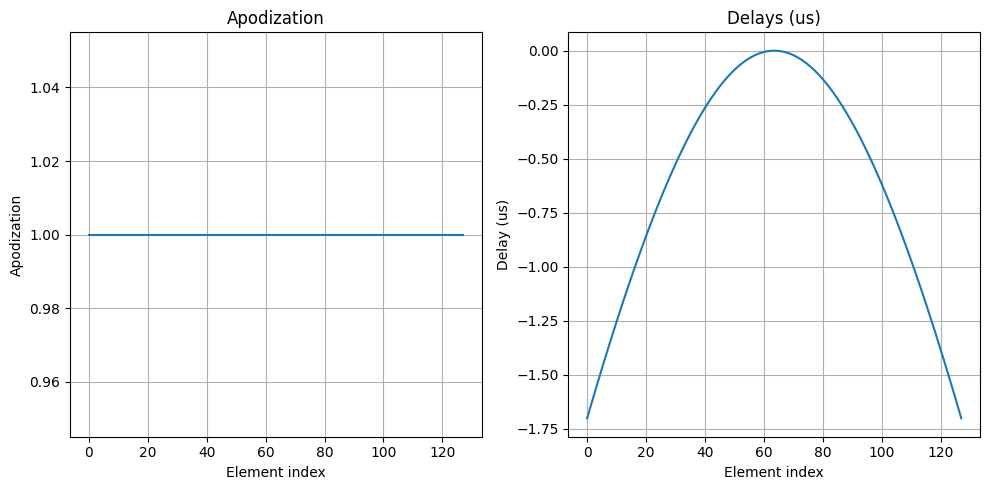

In [28]:
fig = plot_apodization_and_delays(tx)

In [29]:
fieldv1 = PyField_v1(tx)
fieldv2 = PyField(tx)

In [30]:
t_v1, h_v1, events_v1 = fieldv1.spatial_impulse_response(field_point*1e-3, return_all=True)
t_v2, h_v2, events_v2 = fieldv2.spatial_impulse_response(field_point*1e-3, return_all=True)
print(f"Field v1: {h_v1.shape}")
print(f"Field v2: {h_v2.shape}")

Accumulate SIR: 100%|██████████| 1/1 [00:00<00:00, 95.90pt/s]


Total computation time: 0.0178 seconds.
Computing all patch events...
Accumulating SIR from events...
Total computation time: 0.8721 seconds.
Field v1: (32, 1)
Field v2: (32, 1)


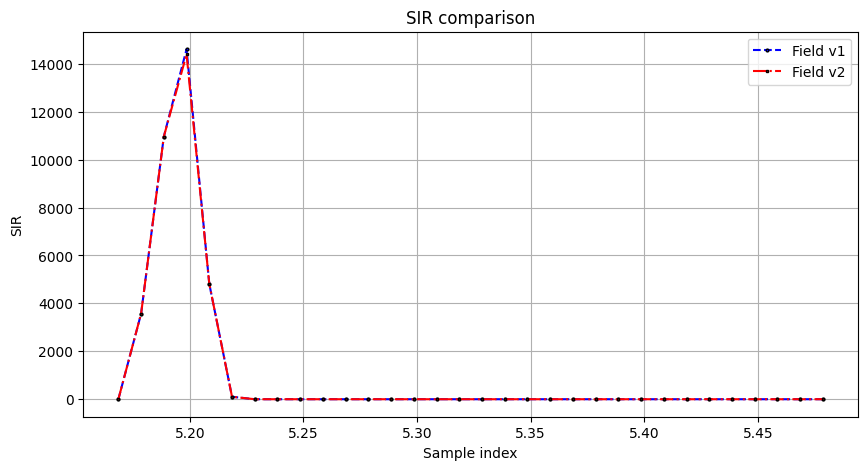

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(t_v1*1e6, h_v1, 'ob--', label="Field v1", ms = 2, markeredgecolor='k')
plt.plot(t_v2*1e6, h_v2, 'sr-.', label="Field v2", ms = 2, markeredgecolor='k')
plt.legend()
plt.title("SIR comparison")
plt.xlabel("Sample index")
plt.ylabel("SIR")
plt.grid()

In [32]:
start_time, h = fieldv2.spatial_impulse_response(grid_points) 

Computing all patch events...
Accumulating SIR from events...
Total computation time: 0.5532 seconds.


In [33]:
pressure_field = compute_pressure_from_SIR(h, x, y, z, [fieldv2.fc, fieldv2.fs])

Original h shape: (512, 2805)
Reshaped h shape: (512, 11, 15, 17)
Frequency searched: 12500000.0 Hz, Closest found: 12524461.839530332 Hz


Taking slice x_ind, y_ind, z_ind = 6/11, 8/15, 9/17


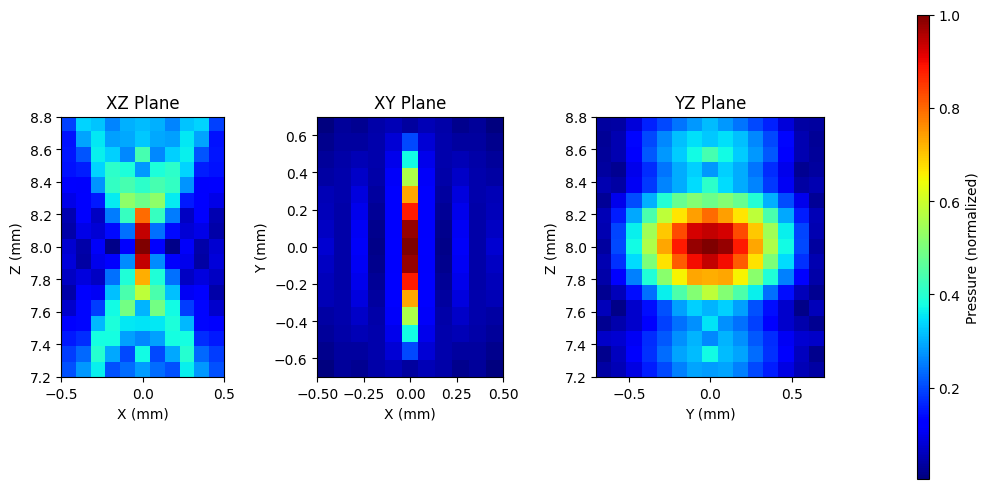

In [34]:
plot_field_planes(pressure_field, x, y, z)

In [35]:
plot_pressure_field(pressure_field, x, y, z)

## 5.1 Let's increase the grid

In [52]:
simulation_struct = {
    "x_extent" : [-0.5e-3, 0.5e-3],
    "y_extent" : [-0.5e-3, 0.5e-3],
    "z_extent" : [7e-3, 9e-3],
    "dx" : 0.02e-3,
    "dy" : 0.05e-3,
    "dz" : 0.02e-3,
}

x, y, z, grid_points = create_simulation_grid(simulation_struct)
print(grid_points.shape, x.shape, y.shape, z.shape)

(106029, 3) (51,) (21,) (99,)


In [53]:
start_time, h = fieldv2.spatial_impulse_response(grid_points) 

Computing all patch events...
Accumulating SIR from events...
Total computation time: 24.9588 seconds.


In [54]:
pressure_field = compute_pressure_from_SIR(h, x, y, z, [field.fc, field.fs])

Original h shape: (512, 106029)
Reshaped h shape: (512, 51, 21, 99)
Frequency searched: 10000000.0 Hz, Closest found: 9980430.528375734 Hz


Taking slice x_ind, y_ind, z_ind = 26/51, 11/21, 50/99


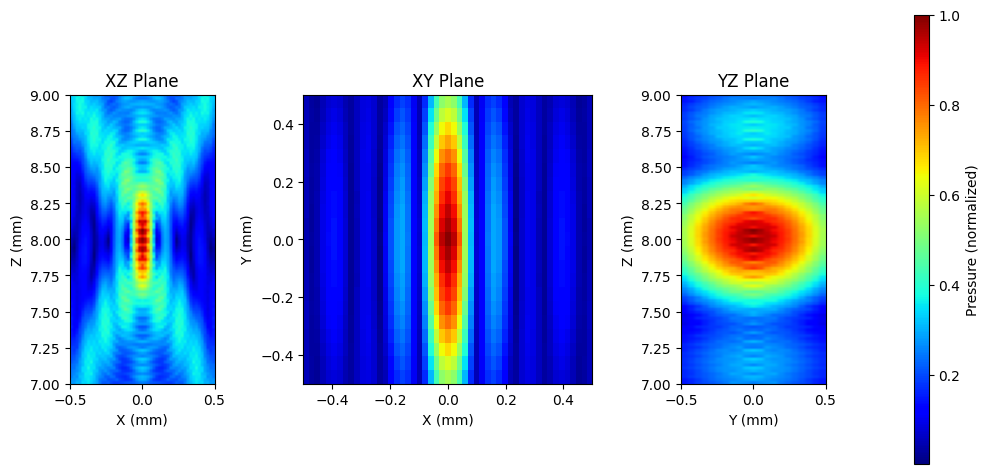

In [55]:
plot_field_planes(pressure_field, x, y, z)

In [40]:
plot_pressure_field(pressure_field, x, y, z)

# 6. Matrix Transducer

In [41]:
import numpy as np
import pyvista as pv
import meshio
from time import time as TIME

class MatrixArrayTransducer:
    """
    Defines a 2D matrix (multi-row) array transducer similar to FieldII's xdc_linear_multirow.
    """
    def __init__(
        self,
        *,
        N_elem_x,
        N_elem_y,
        elem_width_mm,
        elem_height_mm,
        kerf_x_mm,
        kerf_y_mm,
        no_sub_x,
        no_sub_y,
        frequency_Hz=None
    ):
        # Convert mm to meters
        self.n_elem_x = N_elem_x
        self.n_elem_y = N_elem_y
        self.n_elements = N_elem_x * N_elem_y
        self.el_w = elem_width_mm * 1e-3
        self.el_h = elem_height_mm * 1e-3	
        self.kerf_x = kerf_x_mm * 1e-3
        self.kerf_y = kerf_y_mm * 1e-3
        self.no_sub_x = no_sub_x
        self.no_sub_y = no_sub_y
        self.fc = frequency_Hz or 1.0
        # initialize apodization and delays
        total_elements = self.n_elem_x * self.n_elem_y
        self.apodization = np.ones(total_elements, dtype=float)
        self.delays = np.zeros(total_elements, dtype=float)
        # compute element centers in x and y
        total_w = self.n_elem_x * self.el_w + (self.n_elem_x - 1) * self.kerf_x
        total_h = self.n_elem_y * self.el_h + (self.n_elem_y - 1) * self.kerf_y
        start_x = -total_w / 2 + self.el_w / 2
        start_y = -total_h / 2 + self.el_h / 2
        centers = []
        
        for iy in range(self.n_elem_y):
            y = start_y + iy * (self.el_w + self.kerf_y )
            for ix in range(self.n_elem_x):
                x = start_x + ix * (self.el_w + self.kerf_x)
                z = 0.0
                centers.append([x, y, z])
                
        self.element_centers = np.array(centers)
        # subdivisions
        self.sub_quad_verts = []
        self.sub_area = []
        self.sub_el_idx = []
        for idx, center in enumerate(self.element_centers):
            row = idx // self.n_elem_x
            xs = np.linspace(-self.el_w/2, self.el_w/2, self.no_sub_x + 1)
            ys = np.linspace(-self.el_h/2, self.el_h/2, self.no_sub_y + 1)
            for i in range(self.no_sub_x):
                for j in range(self.no_sub_y):
                    corners_local = np.array([
                        [xs[i], ys[j], 0.0], [xs[i+1], ys[j], 0.0],
                        [xs[i+1], ys[j+1], 0.0], [xs[i], ys[j+1], 0.0]
                    ])
                    corners = corners_local + center
                    self.sub_quad_verts.append(corners)
                    self.sub_area.append((self.el_w/self.no_sub_x)*(self.el_h/self.no_sub_y))
                    self.sub_el_idx.append(idx)
        print(f"MatrixArrayTransducer initialized with {total_elements} elements and {len(self.sub_quad_verts)} patches.")

    def set_apodization(self, weights):
        weights = np.asarray(weights, dtype=float)
        if weights.size != self.n_elem_x * self.n_elem_y:
            raise ValueError("Apodization must match total elements")
        self.apodization = weights

    def set_delays(self, delays):
        delays = np.asarray(delays, dtype=float)
        if delays.size != self.n_elem_x * self.n_elem_y:
            raise ValueError("Delays must match total elements")
        self.delays = delays

    def get_mesh(self):
        verts, faces, scalars = [], [], []
        pt_index = 0
        for quad, el_idx in zip(self.sub_quad_verts, self.sub_el_idx):
            verts.extend(quad.tolist())
            faces.append([4, pt_index, pt_index+1, pt_index+2, pt_index+3])
            scalars.append(self.apodization[el_idx])
            pt_index += 4
        verts = np.array(verts)*1e3
        mesh = pv.PolyData(verts, np.hstack(faces))
        mesh.cell_data['Apodization'] = np.array(scalars)
        return mesh


In [42]:
# Create transducer with elevation focus
tx_N_elem_x = 55
tx_N_elem_y = 55
tx_elem_width_mm = 0.29
tx_elem_height_mm = 0.29

tx_pitch_mm = 0.3

tx_kerf_x_mm = tx_pitch_mm - tx_elem_width_mm
tx_kerf_y_mm = tx_pitch_mm - tx_elem_height_mm

tx_freq = 10 # MHz

c = 1540.0  # speed of sound in soft tissue (m/s)

Matrix_Trans = MatrixArrayTransducer(
        N_elem_x        = tx_N_elem_x,
        N_elem_y        = tx_N_elem_y,
        elem_width_mm   = tx_elem_width_mm,
        elem_height_mm  = tx_elem_height_mm,
        kerf_x_mm       = tx_kerf_x_mm,
        kerf_y_mm       = tx_kerf_y_mm,
        no_sub_x        = 3,
        no_sub_y        = 3,
        frequency_Hz    = tx_freq*1e6, 
)

MatrixArrayTransducer initialized with 3025 elements and 27225 patches.


In [43]:
apodization = np.hanning(tx_N_elem_y)[np.newaxis].T + np.hanning(tx_N_elem_x)
apodization = apodization / np.max(apodization)
# Matrix_Trans.set_apodization(apodization.flatten())

In [44]:

delays = np.linalg.norm(Matrix_Trans.element_centers - focus_mm*1e-3, axis=1) / c
delays = delays.min() - delays  # time delays for focusing
Matrix_Trans.set_delays(delays)
# Matrix_Trans.set_apodization(np.random.rand(tx_N_elem_x*tx_N_elem_y))

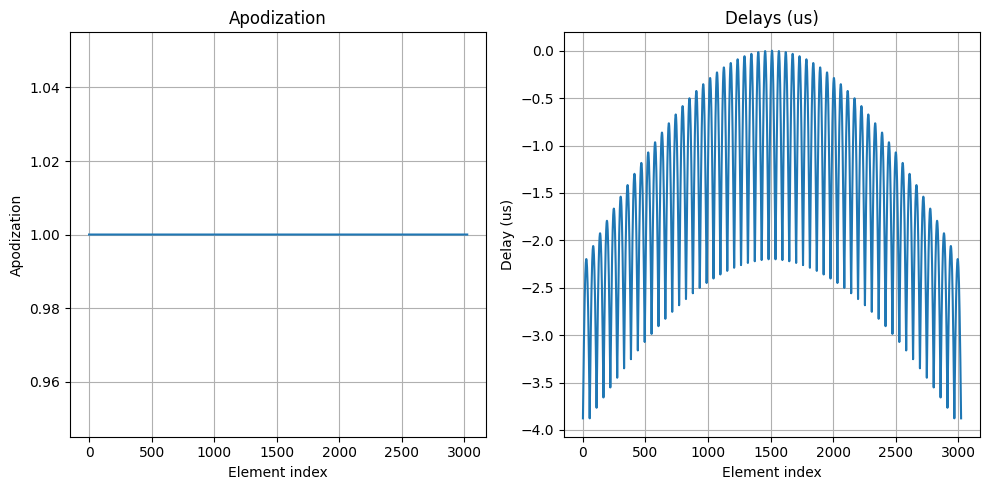

In [45]:
fig = plot_apodization_and_delays(Matrix_Trans)

In [46]:
field = PyField(Matrix_Trans)

In [ ]:

field.show_transducer(notebook=True, show_edges=False)


In [48]:
simulation_struct = {
    "x_extent" : [-0.3e-3, 0.3e-3],
    "y_extent" : [-0.3e-3, 0.3e-3],
    "z_extent" : [7e-3, 9e-3],
    "dx" : 0.2e-4,
    "dy" : 0.2e-4,
    "dz" : 0.4e-4,
}

x, y, z, grid_points = create_simulation_grid(simulation_struct)
print(grid_points.shape, x.shape, y.shape, z.shape)

(41209, 3) (29,) (29,) (49,)


In [49]:
start_time, h = field.spatial_impulse_response(grid_points) 

Computing all patch events...
Accumulating SIR from events...
Total computation time: 202.8231 seconds.


In [50]:
pressure_field = compute_pressure_from_SIR(h, x, y, z, [field.fc, field.fs])

Original h shape: (512, 41209)
Reshaped h shape: (512, 29, 29, 49)
Frequency searched: 10000000.0 Hz, Closest found: 9980430.528375734 Hz


Taking slice x_ind, y_ind, z_ind = 15/29, 15/29, 25/49


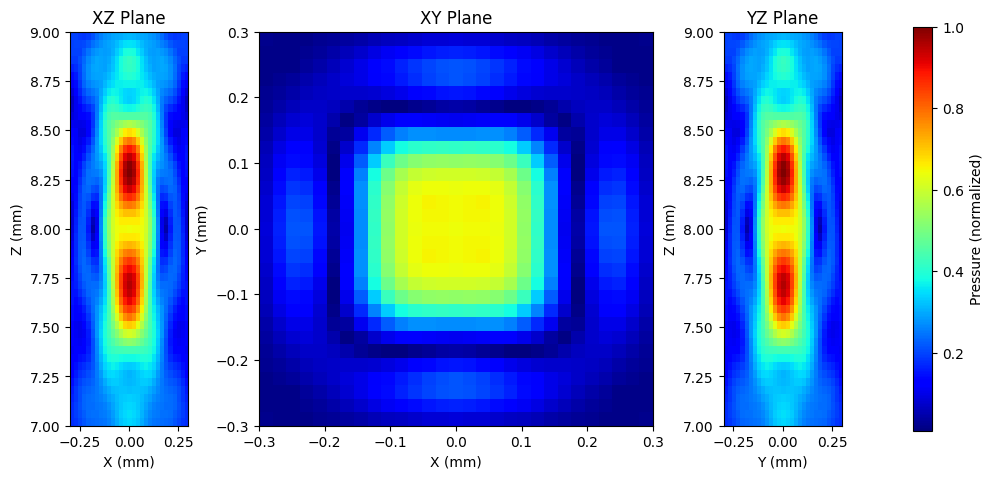

In [51]:
plot_field_planes(pressure_field, x, y, z)